# Modulo 3 - Progetto 1 Algoritmi Fondamentali

1 — Caricamento dataset e analisi iniziale

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans 
from sklearn.metrics import silhouette_score

# Caricamenteo dataset

iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# DataFrame per eplorazione 
df = pd.DataFrame(X, columns=feature_names)

print("Prime righe del dataset:")
display(df.head())

print("\nStatistiche descrittive:")
display(df.describe)

Prime righe del dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Statistiche descrittive:


<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]>

2 — Standardizzazione

In [40]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Media approssimativa dopo scaling:", X_std.mean(axis=0))
print("Deviazione standard approssimativa dopo scaling:", X_std.std(axis=0))

Media approssimativa dopo scaling: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Deviazione standard approssimativa dopo scaling: [1. 1. 1. 1.]


3 — Stima di K con DBSCAN

In [41]:
from sklearn.cluster import dbscan


eps_values = [0.35, 0.45, 0.55]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels_db= dbscan.fit_predict(X_std)

    n_cluster = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = np.sum(labels_db == -1)

    dbscan_results.append({
            "eps" : eps, 
            "n_cluster" : n_cluster,
            "n_noise": n_noise
    })

results_df = pd.DataFrame(dbscan_results)
display(results_df)



,eps,n_cluster,n_noise
0,0.35,4,104
1,0.45,3,54
2,0.55,2,29


4 — Elbow Method con K-Means

In [42]:
wcss = []
k_values = range(1,11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k, 
        init="k-means++",
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_)

5 — Plot dell’Elbow Method

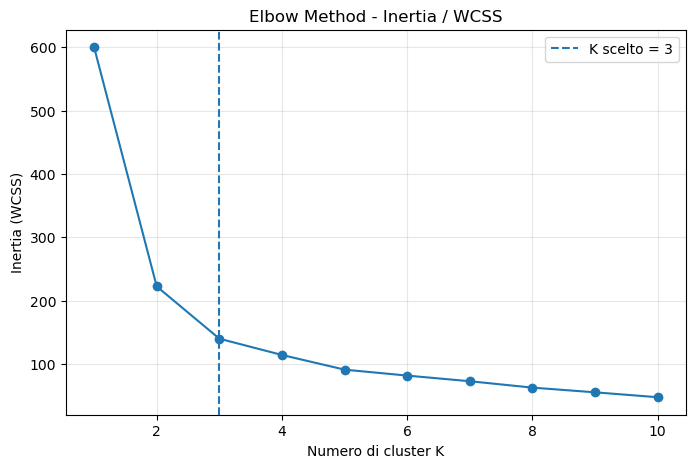

In [43]:
chosen_k = 3

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.axvline(x=chosen_k, linestyle="--", label=f"K scelto = {chosen_k}")

plt.title("Elbow Method - Inertia / WCSS")
plt.xlabel("Numero di cluster K")
plt.ylabel("Inertia (WCSS)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

6 — Scelta del K finale

Ragionamento 

Abbiamo:

DBSCAN:
3 cluster con eps=0.45
2 cluster con eps=0.55
Elbow Method:
suggerisce 3

In [44]:
final_k = 3

7 — K-Means finale

In [45]:
kmeans_final = KMeans(
    n_clusters=final_k, 
    init="k-means++",
    n_init=10,
    random_state=42
)

clusters = kmeans_final.fit_predict(X_std)
centroids_std = kmeans_final.cluster_centers_

8 — Silhouette Score

In [46]:
sil_score = silhouette_score(X_std, clusters)
print(f"Silhouette score con K={final_k}: {sil_score:.4f}")

Silhouette score con K=3: 0.4599


9 — Visualizzazione finale con prime due feature

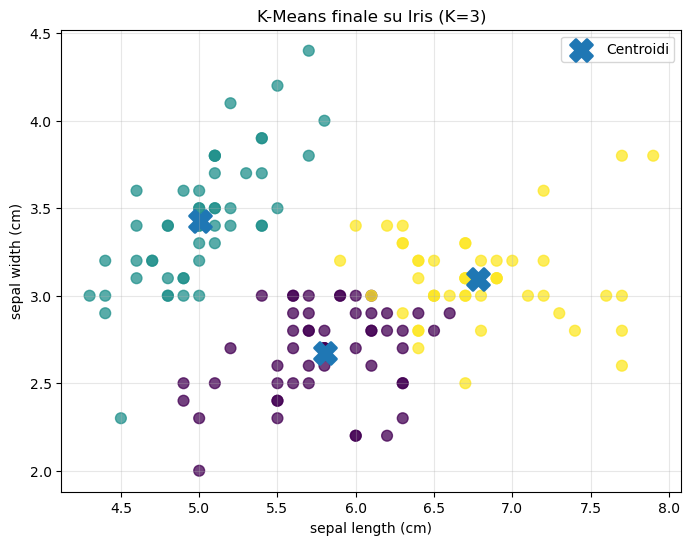

In [47]:
centroids_original = scaler.inverse_transform(centroids_std)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1],
    c=clusters,
    s=60,
    alpha=0.75
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=250,
    linewidths=2,
    label="Centroidi"
)

plt.title(f"K-Means finale su Iris (K={final_k})")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()